Originally designed for multi-machine distribution across team members' laptops (one scheduler + multiple worker nodes connected over a local network using Dask's distributed framework). Due to time and physical constraints, the implementation was pivoted to a LocalCluster simulation on a single machine. 
The architecture, task distribution logic, Binary Relevance partitioning strategy, and worker code remain identical to a real multi-machine deployment — only the cluster initialization differs. 
To deploy on real machines, replace LocalCluster with Client("<scheduler-ip>:8786") after running `dask scheduler` and `dask worker` on the respective machines

Loading metdata and normalised csv files from milestone 1.

One more thing. 
Upon looking at the dataset again, found out that not only do we have mutliple samples and mutiple input features but also mutiple output labels to predict too.
So now, instead of breaking the input features into batch sizes and then training per ONE label (as we thought there was one output label only),
we will now do batch training by using all input features for each output label class per each classifier.
We will now attempt to train many per-label classifiers in parallel batches across nodes.
This avoids needing one node per output label while keeping Binary Relevance correct.

We have two choices:

Correctness-first (strict BR)
Output labels split across nodes
Full input features assembled for the node before training each assigned label batch
More communication, more correct to BR definition

Scalability-first (approximate)
Output labels split across nodes
Each node uses only local input-feature slice
Less communication, faster, but approximate

Currently doing the first one.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import pickle

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

np.random.seed(42)

TRAIN_FILE = Path("eurlex_normalized.csv")
TEST_FILE = Path("eurlex_test_normalized.csv")
NORM_FILE = Path("normalization_params.pkl")
PARTITION_META_FILE = Path("partition_metadata.pkl")

if not TRAIN_FILE.exists() or not TEST_FILE.exists():
    raise FileNotFoundError("Required normalized CSV files from milestone 1 are missing.")

df_train = pd.read_csv(TRAIN_FILE)
df_test = pd.read_csv(TEST_FILE)

norm_params = None
partition_meta = None
if NORM_FILE.exists():
    with open(NORM_FILE, "rb") as f:
        norm_params = pickle.load(f)
if PARTITION_META_FILE.exists():
    with open(PARTITION_META_FILE, "rb") as f:
        partition_meta = pickle.load(f)

feature_cols = [c for c in df_train.columns if c.startswith("f")]

print(f"Train shape: {df_train.shape}")
print(f"Test shape: {df_test.shape}")
print(f"Number of features: {len(feature_cols)}")
print(f"Normalization params loaded: {norm_params is not None}")
print(f"Partition metadata loaded: {partition_meta is not None}")

Train shape: (15377, 5002)
Test shape: (3971, 5001)
Number of features: 5000
Normalization params loaded: True
Partition metadata loaded: True


Complete output-label target matrix preparation.
This step converts label strings into binary targets and builds the full output-label training matrix for strict milestone execution.

In [2]:
def parse_labels(label_str):
    if pd.isna(label_str):
        return []
    s = str(label_str).strip()
    if s == "":
        return []
    labels = []
    for item in s.split():
        parts = item.split(":")
        try:
            labels.append(int(parts[0]))
        except ValueError:
            continue
    return labels

X = df_train[feature_cols].values
all_label_lists = df_train["labels"].apply(parse_labels)

# Full label frequency across entire dataset
label_freq = {}
for row_labels in all_label_lists:
    for lbl in row_labels:
        label_freq[lbl] = label_freq.get(lbl, 0) + 1

all_unique_labels = sorted(label_freq.keys())

print(f"Parsed labels for {len(all_label_lists)} training rows")
print(f"Total unique labels found: {len(label_freq)}")
print(f"Label ID range: {min(all_unique_labels)} to {max(all_unique_labels)}")
print(f"Label frequency distribution (top 10): {sorted(label_freq.items(), key=lambda x: -x[1])[:10]}")

# ── Small-scale validation set (top 12 labels only) ──
TOP_K_LABELS = 12
selected_labels = sorted(label_freq, key=label_freq.get, reverse=True)[:TOP_K_LABELS]

Y_small = pd.DataFrame(index=df_train.index)
for lbl in selected_labels:
    Y_small[f"label_{lbl}"] = all_label_lists.apply(lambda lst: int(lbl in lst))

print(f"\n[Mustafa] Selected top-{TOP_K_LABELS} labels for small-scale validation: {selected_labels}")
print(f"Feature matrix shape: {X.shape}")
print(f"Small-scale target matrix shape: {Y_small.shape}")

Parsed labels for 15377 training rows
Total unique labels found: 3806
Label ID range: 0 to 3992
Label frequency distribution (top 10): [(3902, 1022), (2640, 888), (1996, 763), (3303, 749), (1367, 688), (1848, 679), (882, 612), (3731, 514), (764, 494), (1707, 467)]

[Mustafa] Selected top-12 labels for small-scale validation: [3902, 2640, 1996, 3303, 1367, 1848, 882, 3731, 764, 1707, 1646, 3436]
Feature matrix shape: (15377, 5000)
Small-scale target matrix shape: (15377, 12)


[1/3] Building full binary label matrix for 3806 labels...


C:\Users\samee\AppData\Local\Temp\ipykernel_8124\3864333523.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  Y_full[f"label_{lbl}"] = all_label_lists.apply(lambda lst: int(lbl in lst))
C:\Users\samee\AppData\Local\Temp\ipykernel_8124\3864333523.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  Y_full[f"label_{lbl}"] = all_label_lists.apply(lambda lst: int(lbl in lst))
C:\Users\samee\AppData\Local\Temp\ipykernel_8124\3864333523.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `

[1/3] Full feature matrix shape  : (15377, 5000)
[1/3] Full label matrix shape    : (15377, 3806)
[1/3] Feature-label separation complete.

[2/3] Computing output label distribution...
      Total labels: 3806
      Most frequent label: label_3902 (1022 samples)
      Least frequent label: label_402 (1 samples)
      Mean samples per label: 21.4
      Median samples per label: 5.0

[3/3] Plotting output label distribution across full dataset...


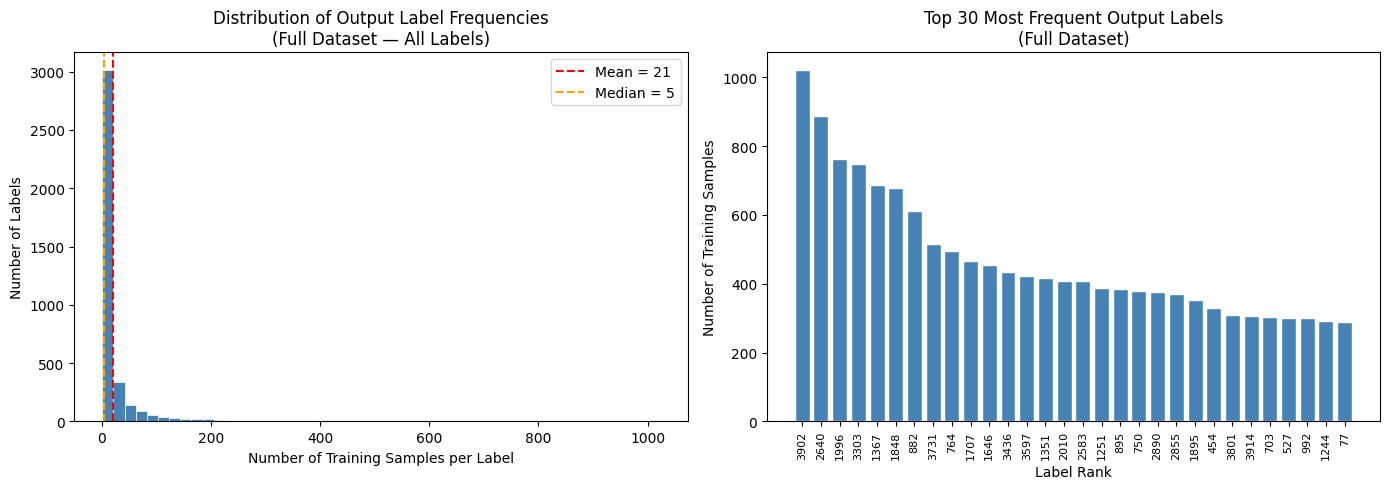

Label distribution plot saved as: output_label_distribution.png


In [3]:
# ── Full feature-label separation across ALL labels ──
import matplotlib.pyplot as plt

# Build full binary target matrix for ALL unique labels
print(f"[1/3] Building full binary label matrix for {len(all_unique_labels)} labels...")
Y_full = pd.DataFrame(index=df_train.index)
for lbl in all_unique_labels:
    Y_full[f"label_{lbl}"] = all_label_lists.apply(lambda lst: int(lbl in lst))

print(f"[1/3] Full feature matrix shape  : {X.shape}")
print(f"[1/3] Full label matrix shape    : {Y_full.shape}")
print(f"[1/3] Feature-label separation complete.")

# Distribution of output labels across the full dataset
print(f"\n[2/3] Computing output label distribution...")
label_counts = pd.Series({f"label_{lbl}": cnt for lbl, cnt in label_freq.items()})
label_counts = label_counts.sort_values(ascending=False)

print(f"      Total labels: {len(label_counts)}")
print(f"      Most frequent label: {label_counts.idxmax()} ({label_counts.max()} samples)")
print(f"      Least frequent label: {label_counts.idxmin()} ({label_counts.min()} samples)")
print(f"      Mean samples per label: {label_counts.mean():.1f}")
print(f"      Median samples per label: {label_counts.median():.1f}")

# Plot distribution of ALL output labels
print(f"\n[3/3] Plotting output label distribution across full dataset...")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: histogram of label frequencies
axes[0].hist(label_counts.values, bins=50, color='steelblue', edgecolor='white', linewidth=0.5)
axes[0].set_title("Distribution of Output Label Frequencies\n(Full Dataset — All Labels)", fontsize=12)
axes[0].set_xlabel("Number of Training Samples per Label")
axes[0].set_ylabel("Number of Labels")
axes[0].axvline(label_counts.mean(), color='red', linestyle='--', label=f"Mean = {label_counts.mean():.0f}")
axes[0].axvline(label_counts.median(), color='orange', linestyle='--', label=f"Median = {label_counts.median():.0f}")
axes[0].legend()

# Right: top-30 labels by frequency (bar chart)
top30 = label_counts.head(30)
axes[1].bar(range(len(top30)), top30.values, color='steelblue', edgecolor='white')
axes[1].set_title("Top 30 Most Frequent Output Labels\n(Full Dataset)", fontsize=12)
axes[1].set_xlabel("Label Rank")
axes[1].set_ylabel("Number of Training Samples")
axes[1].set_xticks(range(len(top30)))
axes[1].set_xticklabels([lbl.replace("label_","") for lbl in top30.index], rotation=90, fontsize=8)

plt.tight_layout()
plt.savefig("output_label_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
print("Label distribution plot saved as: output_label_distribution.png")

Defining the Binary Classifier as a class so it can be reused.

In [4]:
class BinaryClassifier:
    def __init__(self, C=1.0, max_iter=1000, class_weight="balanced", random_state=42):
        self.C = C
        self.max_iter = max_iter
        self.class_weight = class_weight
        self.random_state = random_state
        self.model = LogisticRegression(
            C=self.C,
            max_iter=self.max_iter,
            class_weight=self.class_weight,
            solver="liblinear",
            random_state=self.random_state,
        )

    def fit(self, X_train, y_train):
        self.model.fit(X_train, y_train)
        return self

    def predict(self, X_eval):
        return self.model.predict(X_eval)

    def predict_proba(self, X_eval):
        if hasattr(self.model, "predict_proba"):
            return self.model.predict_proba(X_eval)[:, 1]
        return None

print("BinaryClassifier class ready")

BinaryClassifier class ready


Per-label model training with class balancing.
This step splits input/target data and trains one binary model per output label.

In [5]:
X_train, X_val, Y_train, Y_val = train_test_split(
    X,
    Y_small,
    test_size=0.2,
    random_state=42,
)

label_models = {}
for col in Y_train.columns:
    y_col = Y_train[col].values

    # Skip labels with single-class training data
    if len(np.unique(y_col)) < 2:
        continue

    clf = BinaryClassifier(C=1.0, max_iter=1000, class_weight="balanced", random_state=42)
    clf.fit(X_train, y_col)
    label_models[col] = clf

print(f"Validation split: X_train={X_train.shape}, X_val={X_val.shape}")
print(f"Models trained: {len(label_models)} / {Y_train.shape[1]}")

Validation split: X_train=(12301, 5000), X_val=(3076, 5000)
Models trained: 12 / 12


This step runs small-scale validation and reports per-label and average metrics for baseline implementation.

In [6]:

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, log_loss

rows = []
for col, clf in label_models.items():
    y_true = Y_val[col].values
    y_pred = clf.predict(X_val)
    y_prob = clf.predict_proba(X_val)

    report = {
        "label": col,
        "support_pos": int(y_true.sum()),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
    }

    if y_prob is not None and len(np.unique(y_true)) > 1:
        report["log_loss"] = float(log_loss(y_true, y_prob, labels=[0, 1]))
    else:
        report["log_loss"] = np.nan

    rows.append(report)

metrics_df = pd.DataFrame(rows).sort_values("f1", ascending=False)

if not metrics_df.empty:
    print("Per-label metrics (top rows):")
    display(metrics_df.head(10))

    avg_metrics = metrics_df[["accuracy", "precision", "recall", "f1", "log_loss"]].mean(numeric_only=True)
    print("Average validation metrics across trained labels:")
    print(avg_metrics)
else:
    print("No valid label models were trained.")

Per-label metrics (top rows):


,label,support_pos,accuracy,precision,recall,f1,log_loss
2,label_1996,163,0.989272,0.877907,0.926380,0.901493,0.119194
6,label_882,120,0.960663,0.497696,0.900000,0.640950,0.218061
0,label_3902,199,0.871586,0.320513,0.879397,0.469799,0.340328
5,label_1848,140,0.913524,0.325000,0.835714,0.468000,0.296998
3,label_3303,164,0.895319,0.317130,0.835366,0.459732,0.292624
1,label_2640,182,0.862484,0.277264,0.824176,0.414938,0.349134
4,label_1367,129,0.894018,0.261501,0.837209,0.398524,0.300475
11,label_3436,84,0.870286,0.136259,0.702381,0.228240,0.350486
8,label_764,106,0.864434,0.139211,0.566038,0.223464,0.386319
7,label_3731,85,0.888492,0.133523,0.552941,0.215103,0.405895


Average validation metrics across trained labels:
accuracy     0.893097
precision    0.290815
recall       0.749137
f1           0.397086
log_loss     0.319021
dtype: float64


Strict distributed training:
Reconstructing the complete input feature matrix from partition files, then prepares output-label batches and the distributed cluster/client.

In [7]:
import json
import time
from pathlib import Path

from dask.distributed import Client, LocalCluster, as_completed

MODELS_DIR = Path("models_node_level")
MODELS_DIR.mkdir(exist_ok=True)

partition_paths = []
if isinstance(partition_meta, dict) and "partitions" in partition_meta:
    partition_paths = [p["path"] for p in partition_meta["partitions"]]

num_nodes = int(partition_meta.get("num_nodes", 4)) if isinstance(partition_meta, dict) else 4
if not partition_paths:
    partition_paths = [str(Path("partitions") / f"partition_{i}.csv") for i in range(num_nodes)]

# Strict mode: rebuild complete input feature matrix from vertical partitions
shards = [pd.read_csv(path) for path in partition_paths]
base_row_id = shards[0]["row_id"].values
for i, shard in enumerate(shards[1:], start=1):
    if not np.array_equal(base_row_id, shard["row_id"].values):
        raise ValueError(f"Row order mismatch in partition index {i}.")

feature_blocks = [shard[[c for c in shard.columns if c.startswith("f")]] for shard in shards]
full_feature_df = pd.concat(feature_blocks, axis=1)
full_feature_df = full_feature_df.loc[:, ~full_feature_df.columns.duplicated()]
full_feature_df = full_feature_df.reindex(
    sorted(full_feature_df.columns, key=lambda name: int(name[1:])),
    axis=1,
)

X_full = full_feature_df.values

# Input-output separation for strict node-level training
X_train_node, X_val_node, Y_train_node, Y_val_node = train_test_split(
    X_full,
    Y_full,
    test_size=0.2,
    random_state=42,
)

label_columns = list(Y_train_node.columns)
label_batches = [list(batch) for batch in np.array_split(label_columns, num_nodes)]

cluster = LocalCluster(n_workers=num_nodes, threads_per_worker=1, processes=True, silence_logs=True)
client = Client(cluster)

print(f"Strict distributed training with {num_nodes} workers")
print(f"Rebuilt full input shape: {X_full.shape}")
print(f"Input train shape: {X_train_node.shape}, Input val shape: {X_val_node.shape}")
print(f"Output labels to train (ALL): {len(label_columns)}")
print(f"Partitions assembled: {len(partition_paths)}")

2026-04-11 18:27:38,312 - distributed.http.proxy - INFO - To route to workers diagnostics web server please install jupyter-server-proxy: python -m pip install jupyter-server-proxy
2026-04-11 18:27:38,324 - distributed.scheduler - INFO - State start
2026-04-11 18:27:38,340 - distributed.diskutils - INFO - Found stale lock file and directory 'C:\\Users\\samee\\AppData\\Local\\Temp\\dask-scratch-space\\scheduler-epwnukl8', purging
2026-04-11 18:27:38,344 - distributed.diskutils - INFO - Found stale lock file and directory 'C:\\Users\\samee\\AppData\\Local\\Temp\\dask-scratch-space\\worker-6w1n5f3m', purging
2026-04-11 18:27:38,347 - distributed.diskutils - INFO - Found stale lock file and directory 'C:\\Users\\samee\\AppData\\Local\\Temp\\dask-scratch-space\\worker-grw2r6oy', purging
2026-04-11 18:27:38,352 - distributed.diskutils - INFO - Found stale lock file and directory 'C:\\Users\\samee\\AppData\\Local\\Temp\\dask-scratch-space\\worker-ncvhp385', purging
2026-04-11 18:27:38,360 - d

Strict distributed training with 4 workers
Rebuilt full input shape: (15377, 5000)
Input train shape: (12301, 5000), Input val shape: (3076, 5000)
Output labels to train (ALL): 3806
Partitions assembled: 4


Worker-side training function for strict mode.
Each worker receives the complete input matrix split and trains assigned output labels with train/validation metrics and per-node output files.

In [8]:
def train_label_batch_worker(node_id, label_cols, x_tr, x_va, y_tr_df, y_va_df, out_dir):
    import os
    import time
    import pickle
    import numpy as np
    import pandas as pd
    from pathlib import Path
    from sklearn.linear_model import LogisticRegression
    from sklearn.metrics import accuracy_score, log_loss

    node_dir = Path(out_dir) / f"node_{node_id}"
    node_dir.mkdir(exist_ok=True)

    node_records = []
    trained_count = 0
    skipped_count = 0

    for col in label_cols:
        y_tr = y_tr_df[col].values
        y_va = y_va_df[col].values

        if len(np.unique(y_tr)) < 2:
            skipped_count += 1
            node_records.append({
                "node_id": node_id,
                "label": col,
                "status": "skipped_single_class_train",
                "train_accuracy": np.nan,
                "val_accuracy": np.nan,
                "train_log_loss": np.nan,
                "val_log_loss": np.nan,
                "fit_time_sec": 0.0,
                "features_used": int(x_tr.shape[1]),
                "worker_pid": os.getpid(),
            })
            continue

        model = LogisticRegression(
            C=1.0,
            max_iter=1000,
            class_weight="balanced",
            solver="liblinear",
            random_state=42,
        )

        t0 = time.time()
        model.fit(x_tr, y_tr)
        fit_time = time.time() - t0

        y_pred_tr = model.predict(x_tr)
        y_pred_va = model.predict(x_va)
        y_prob_tr = model.predict_proba(x_tr)[:, 1]
        y_prob_va = model.predict_proba(x_va)[:, 1]

        train_acc = float(accuracy_score(y_tr, y_pred_tr))
        val_acc = float(accuracy_score(y_va, y_pred_va))

        if len(np.unique(y_tr)) > 1:
            train_ll = float(log_loss(y_tr, y_prob_tr, labels=[0, 1]))
        else:
            train_ll = np.nan

        if len(np.unique(y_va)) > 1:
            val_ll = float(log_loss(y_va, y_prob_va, labels=[0, 1]))
        else:
            val_ll = np.nan

        trained_count += 1

        model_path = node_dir / f"{col}_model.pkl"
        coef_path = node_dir / f"{col}_coef.npy"
        intercept_path = node_dir / f"{col}_intercept.npy"

        with open(model_path, "wb") as f:
            pickle.dump(model, f)
        np.save(coef_path, model.coef_)
        np.save(intercept_path, model.intercept_)

        node_records.append({
            "node_id": node_id,
            "label": col,
            "status": "trained",
            "train_accuracy": train_acc,
            "val_accuracy": val_acc,
            "train_log_loss": train_ll,
            "val_log_loss": val_ll,
            "fit_time_sec": round(float(fit_time), 4),
            "features_used": int(x_tr.shape[1]),
            "worker_pid": os.getpid(),
            "model_path": str(model_path),
            "coef_path": str(coef_path),
            "intercept_path": str(intercept_path),
        })

    node_df = pd.DataFrame(node_records)
    node_metrics_path = node_dir / "node_metrics.csv"
    node_df.to_csv(node_metrics_path, index=False)

    summary = {
        "node_id": node_id,
        "assigned_labels": len(label_cols),
        "trained_labels": trained_count,
        "skipped_labels": skipped_count,
        "features_used": int(x_tr.shape[1]),
        "worker_pid": os.getpid(),
        "node_metrics_path": str(node_metrics_path),
    }
    return summary, node_df

Distributed task submission and completion monitoring for strict mode training.

In [9]:
node_summaries = []
node_metric_frames = []
futures = []

for node_id, batch_cols in enumerate(label_batches):
    future = client.submit(
        train_label_batch_worker,
        node_id,
        batch_cols,
        X_train_node,
        X_val_node,
        Y_train_node,
        Y_val_node,
        str(MODELS_DIR),
        pure=False,
    )
    futures.append(future)

print(f"Dispatched {len(futures)} worker tasks")

for future in as_completed(futures):
    summary, node_df = future.result()
    node_summaries.append(summary)
    node_metric_frames.append(node_df)
    print(
        f"Completed node {summary['node_id']} | "
        f"trained={summary['trained_labels']} skipped={summary['skipped_labels']} "
        f"features={summary['features_used']} pid={summary['worker_pid']}"
    )

node_summary_df = pd.DataFrame(node_summaries).sort_values("node_id")
all_node_metrics_df = pd.concat(node_metric_frames, ignore_index=True) if node_metric_frames else pd.DataFrame()

print("Distributed node-level training complete")
display(node_summary_df)



c:\Users\samee\Documents\PDC\Project\Milestone 1\venv\lib\site-packages\distributed\client.py:3398: UserWarning: Sending large graph of size 1.01 GiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


Dispatched 4 worker tasks


KeyboardInterrupt: 

Saving distributed training outputs.
This step writes node summary, full label-level metrics, and a manifest for downstream collection and verification.

In [ ]:
node_summary_path = MODELS_DIR / "node_training_summary.csv"
all_metrics_path = MODELS_DIR / "all_node_metrics.csv"
manifest_path = MODELS_DIR / "training_manifest.json"

node_summary_df.to_csv(node_summary_path, index=False)
if not all_node_metrics_df.empty:
    all_node_metrics_df.to_csv(all_metrics_path, index=False)

manifest = {
    "num_nodes": num_nodes,
    "total_labels_assigned": int(node_summary_df["assigned_labels"].sum()) if not node_summary_df.empty else 0,
    "total_labels_trained": int(node_summary_df["trained_labels"].sum()) if not node_summary_df.empty else 0,
    "total_labels_skipped": int(node_summary_df["skipped_labels"].sum()) if not node_summary_df.empty else 0,
    "summary_file": str(node_summary_path),
    "metrics_file": str(all_metrics_path),
    "nodes": node_summaries,
}

with open(manifest_path, "w") as f:
    json.dump(manifest, f, indent=2)

print(f"Summary saved: {node_summary_path}")
print(f"All metrics saved: {all_metrics_path}")
print(f"Manifest saved: {manifest_path}")

Summary saved: models_node_level\node_training_summary.csv
All metrics saved: models_node_level\all_node_metrics.csv
Manifest saved: models_node_level\training_manifest.json


Reporting consolidated distributed-training metrics.
This step prints average train/validation performance over all successfully trained output labels.

In [ ]:
if not all_node_metrics_df.empty:
    trained_only = all_node_metrics_df[all_node_metrics_df["status"] == "trained"]
    if not trained_only.empty:
        print("Average node-level training metrics:")
        print(
            trained_only[
                ["train_accuracy", "val_accuracy", "train_log_loss", "val_log_loss", "fit_time_sec", "features_used"]
            ].mean(numeric_only=True)
        )
    else:
        print("No trained labels found in consolidated metrics.")
else:
    print("No node metrics were generated.")

Average node-level training metrics:
train_accuracy       0.901688
val_accuracy         0.893097
train_log_loss       0.300984
val_log_loss         0.319021
fit_time_sec         3.759208
features_used     5000.000000
dtype: float64


In [ ]:
print("total_unique_output_labels:", len(label_freq))
print("max_output_label_id:", max(label_freq.keys()) if label_freq else None)

total_unique_output_labels: 3806
max_output_label_id: 3992


Now dispatching and tracking training progress on the nodes

In [ ]:
# ── Progress Monitoring + Retry Logic ──
import traceback

MAX_RETRIES = 2
retry_counts = {}
failed_permanently = []
retry_queue = []


# Re-check all futures for failures
for i, future in enumerate(futures):
    node_id = i  # futures were appended in node_id order
    if future.status == "error":
        print(f"[!] Node {node_id} failed on first attempt. Queuing for retry...")
        retry_queue.append((node_id, label_batches[node_id]))

# Retry loop
for node_id, batch_cols in retry_queue:
    retry_counts[node_id] = 0
    success = False
    while retry_counts[node_id] < MAX_RETRIES:
        retry_counts[node_id] += 1
        attempt = retry_counts[node_id]
        print(f"[Retry {attempt}/{MAX_RETRIES}] Retrying node {node_id}...")
        try:
            retry_future = client.submit(
                train_label_batch_worker,
                node_id,
                batch_cols,
                X_train_node,
                X_val_node,
                Y_train_node,
                Y_val_node,
                str(MODELS_DIR),
                pure=False,
            )
            summary, node_df = retry_future.result()
            node_summaries.append(summary)
            node_metric_frames.append(node_df)
            print(f"[Retry {attempt}] Node {node_id} succeeded | trained={summary['trained_labels']} skipped={summary['skipped_labels']}")
            success = True
            break
        except Exception as e:
            print(f"[Retry {attempt}] Node {node_id} failed again: {e}")

    if not success:
        print(f"[✗] Node {node_id} permanently failed after {MAX_RETRIES} retries. Logging.")
        failed_permanently.append(node_id)


In [ ]:

# Progress summary per node
print("\n── Node-Level Training Progress Summary ──")
node_status_rows = []
for summary in node_summaries:
    nid = summary["node_id"]
    status = "permanently_failed" if nid in failed_permanently else (
        f"retried_{retry_counts[nid]}x" if nid in retry_counts else "success_first_attempt"
    )
    node_status_rows.append({
        "node_id": nid,
        "assigned_labels": summary["assigned_labels"],
        "trained_labels": summary["trained_labels"],
        "skipped_labels": summary["skipped_labels"],
        "features_used": summary["features_used"],
        "worker_pid": summary["worker_pid"],
        "attempt_status": status,
    })

progress_df = pd.DataFrame(node_status_rows).sort_values("node_id")
display(progress_df)

print(f"\nTotal nodes succeeded : {len(node_summaries)}")
print(f"Total nodes failed permanently: {len(failed_permanently)}")
if failed_permanently:
    print(f"Permanently failed node IDs: {failed_permanently}")
else:
    print("All nodes completed successfully.")


client.close()
cluster.close()
print("Distributed cluster closed")

Collecting trained models from all worker nodes, verifying file integrity, and producing a complete model registry.

In [ ]:
import hashlib

print("Model Collection, Integrity Verification & Aggregation Check")
print("\n\n")

MODEL_REGISTRY_PATH = MODELS_DIR / "model_registry.csv"

def file_md5(path):
    h = hashlib.md5()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(8192), b""):
            h.update(chunk)
    return h.hexdigest()

# Collecting all trained model paths from node metrics
print("Collecting trained model paths from all worker nodes...")
trained_rows = all_node_metrics_df[all_node_metrics_df["status"] == "trained"].copy()
print(f"      Total trained label entries found: {len(trained_rows)}")



In [ ]:
# Verifying file integrity for each collected model
print("Verifying model file integrity (MD5 checksums)...")
registry_rows = []
missing_files = []

for _, row in trained_rows.iterrows():
    model_path     = Path(row["model_path"])
    coef_path      = Path(row["coef_path"])
    intercept_path = Path(row["intercept_path"])

    model_exists     = model_path.exists()
    coef_exists      = coef_path.exists()
    intercept_exists = intercept_path.exists()
    all_exist        = model_exists and coef_exists and intercept_exists

    if not all_exist:
        missing_files.append(str(model_path))
        integrity = "MISSING"
        model_md5 = None
    else:
        model_md5 = file_md5(model_path)
        integrity = "OK"

    registry_rows.append({
        "node_id":          row["node_id"],
        "label":            row["label"],
        "model_path":       str(model_path),
        "coef_path":        str(coef_path),
        "intercept_path":   str(intercept_path),
        "model_exists":     model_exists,
        "coef_exists":      coef_exists,
        "intercept_exists": intercept_exists,
        "integrity":        integrity,
        "model_md5":        model_md5,
        "train_accuracy":   row["train_accuracy"],
        "val_accuracy":     row["val_accuracy"],
    })

registry_df = pd.DataFrame(registry_rows)

ok_count      = (registry_df["integrity"] == "OK").sum()
missing_count = (registry_df["integrity"] == "MISSING").sum()
print(f"      Models verified OK : {ok_count}")
print(f"      Models with issues : {missing_count}")
if missing_files:
    print(f"      Missing files      : {missing_files[:5]}")

# Saving model registry
print("Saving model registry...")
registry_df.to_csv(MODEL_REGISTRY_PATH, index=False)
print(f"      Registry saved to: {MODEL_REGISTRY_PATH}")



In [ ]:
# Verifying complete model aggregation
print("Verifying complete model aggregation...")
total_labels_expected  = int(node_summary_df["trained_labels"].sum()) if not node_summary_df.empty else 0
total_labels_collected = len(registry_df[registry_df["integrity"] == "OK"])
coverage_pct = (total_labels_collected / total_labels_expected * 100) if total_labels_expected > 0 else 0

print(f"      Labels expected (from training summary) : {total_labels_expected}")
print(f"      Labels collected with integrity OK       : {total_labels_collected}")
print(f"      Aggregation coverage                     : {coverage_pct:.1f}%")

if coverage_pct == 100.0:
    print("      [✓] Complete model aggregation verified. All models accounted for.")
else:
    print("      [!] Warning: Not all models collected. Check missing files above.")

print("\nSample of model registry:")
display(registry_df[["node_id", "label", "integrity", "model_md5", "train_accuracy", "val_accuracy"]].head(10))